In [1]:
# Cài thư viện cần thiết (idempotent - no-op nếu đã có)
%pip install --quiet pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\FPT\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


# EDA - Giao dịch tài chính PaySim (phát hiện gian lận)

Notebook EDA cho dataset mô phỏng giao dịch tài chính di động PaySim (~6.36 triệu dòng).
Mục tiêu: **phát hiện gian lận** (`isFraud`), nhưng EDA này chỉ làm **bằng chứng + khuyến nghị**, không thay thế modeling.

- Cột mục tiêu: `isFraud` (1 = gian lận). `isFlaggedFraud` là cờ cảnh báo thủ công (chỉ gắn cờ giao dịch rất lớn).
- Mỗi phân tích gồm **Câu hỏi / Tìm thấy / Hàm ý cho modeling** (nguyên tắc 20/80: ưu tiên phân tích ảnh hưởng đến preprocessing, feature engineering, chọn model, cách đánh giá).
- Dữ liệu lớn (540MB) → ghi rõ chiến lược lấy mẫu khi dùng sample, các bảng tổng hợp dùng full data.
- Nhận xét cuối mỗi Section: **Key Findings** và **Modeling Implications**.

## ⚠️ Cảnh báo trước - Leakage ở cột số dư (bằng chứng ở Section 8)

Trong PaySim, dòng gian lận được mô phỏng bằng cách **rút sạch tài khoản nguồn**:
`oldbalanceOrig == amount` và `newbalanceOrig == 0` (không phải "giao dịch bị huỷ nên số dư không đổi" - diễn giải phổ biến nhưng sai).

- Quy tắc `oldbalanceOrg == amount` trên TRANSFER/CASH_OUT khớp **8.034/8.213** fraud và **0 dòng hợp lệ** → precision 1.0 không hợp lệ phải có → model học được nó là **máy nhận diện fingerprint, không học gì về hành vi gian lận**.
- **4 cột balance KHÔNG được đưa vào feature.** Chúng chỉ dùng trong Section 8 (diagnostic chứng minh leakage) và Section 9 (kiểm tra tính nhất quán dữ liệu).

## 1. Dataset Understanding

**Câu hỏi:** Dữ liệu là gì? Mỗi dòng là gì? Cột nào là event / entity-id / post-event / target?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", "{:.2f}".format)

DATA = "data/archive/PS_20174392719_1491204439457_log.csv"

# dtypes gọn để giảm RAM (file ~540MB → ~250MB)
dtypes = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(DATA, dtype=dtypes)
print(f"Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} cột")
df.head(6)

Kích thước: 6,362,620 dòng x 11 cột


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.00,0.00,0,0


**Data dictionary** - 4 nhóm cột:

| Nhóm | Cột | Ý nghĩa |
|---|---|---|
| Thời gian | `step` | Đơn vị 1 giờ mô phỏng (1..743, không phải timestamp thật, không liên tục độ dài thực) |
| Event | `type`, `amount` | Loại giao dịch, số tiền |
| Entity | `nameOrig`, `nameDest` | ID tài khoản nguồn / ID tài khoản đích (`C` = khách hàng, `M` = merchant) |
| Post-event | 4 cột balance | Số dư trước/sau 2 phía - **không có tại thời điểm dự đoán** (xem Section 8) |
| Target | `isFraud`, `isFlaggedFraud` | Nhãn gian lận của generator / cờ cảnh báo thủ công |

In [3]:
# Đánh giá nhanh từng cột: cardinality + 1 giá trị mẫu
summary = {}
for c in df.columns:
    summary[c] = [str(df[c].dtype), f"{df[c].nunique():,}", df[c].dropna().iloc[0]]
card = pd.DataFrame(summary, index=["dtype", "n_unique", "sample_0"]).T
card

,dtype,n_unique,sample_0
step,int16,743,1
type,category,5,PAYMENT
amount,float32,"5,236,933",9839.64
nameOrig,object,"6,353,307",C1231006815
oldbalanceOrg,float32,"1,834,373",170136.00
newbalanceOrig,float32,"2,663,280",160296.36
nameDest,object,"2,722,362",M1979787155
oldbalanceDest,float32,"3,532,215",0.00
newbalanceDest,float32,"3,474,507",0.00
isFraud,int8,2,0


In [4]:
#### Entity-id hay feature?
# nameOrig gần như độc nhất -> ứng viên ROW ID, aggregate theo tài khoản gần như vô dụng
for c in ["nameOrig", "nameDest"]:
    nu, n = df[c].nunique(), len(df)
    print(f"{c}: {nu:,} unique / {n:,} dòng = {nu/n*100:.2f}%  ({n-nu:,} tài khoản lặp lại)")
unq_step, unq_type = df["step"].nunique(), df["type"].nunique()
print(f"step: {unq_step} mức;  type: {unq_type} mức")

nameOrig: 6,353,307 unique / 6,362,620 dòng = 99.85%  (9,313 tài khoản lặp lại)


nameDest: 2,722,362 unique / 6,362,620 dòng = 42.79%  (3,640,258 tài khoản lặp lại)
step: 743 mức;  type: 5 mức


**Key Findings - §1**
1. Dữ liệu sạch schema, không thiếu giá trị, 0 dòng trùng lặp (chi tiết Section 2).
2. `nameOrig` gần như **mỗi dòng một tài khoản riêng** (99.85% unique) → dùng nó làm feature thì nó là row-id, không phải thông tin hành vi; aggregate theo nguồn rất nghèo nàn.
3. `nameDest` lặp lại nhiều hơn (2.72M unique) → tần suất quen thuộc của đích có thể hữu ích (kiểm tra ở Section 5).
4. `step` chỉ là **chỉ số giờ mô phỏng** (743 mức), không phải thời gian thực - cẩn thận khi suy diễn "seasonality thật".

**Modeling Implications - §1**
- Giữ `type`, `amount`, `(step)`, `nameDest`(dạng nén: tiền tố C/M, tần suất). Không dùng `nameOrig` thô (cardinality cao vô nghĩa), không dùng 4 cột balance (leakage).
- Các cột entity-id chỉ nên đưa ra dạng **count/frequency encode** nếu cần.

## 2. Data Quality

**Câu hỏi:** Có thiếu giá trị, trùng lặp, cột gần-hằng-số, giá trị bất hợp lý (amount ≤ 0, số âm, "0 mà thực chất là unknown")?

In [5]:
print("Đánh trùng lặp:", df.duplicated().sum())
print("Giá trị thiếu:", df.isna().sum().sum())
print("Giá trị âm - amount:", (df["amount"] < 0).sum(), "| balance:", (df[[
    "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]] < 0).sum().sum())

# Cột gần-hằng-số: isFlaggedFraud có 6.36M/6.36M = chủ yếu 1 giá trị
print("\nPhân bố isFlaggedFraud:", dict(df["isFlaggedFraud"].value_counts()))

Đánh trùng lặp: 0


Giá trị thiếu: 0
Giá trị âm - amount: 0 | balance: 0

Phân bố isFlaggedFraud: {0: np.int64(6362604), 1: np.int64(16)}


In [6]:
#### Bất thường: amount = 0
# Có chính xác 16 dòng amount==0, TẤT CẢ là fraud (xem anomaly ở Section 9) - generator edge case
z = df[df["amount"] == 0]
print(f"amount==0: {len(z)} dòng, fraud chiếm {z['isFraud'].mean():.0%}, ")
print(f"loại: {dict(z['type'].value_counts())}")

amount==0: 16 dòng, fraud chiếm 100%, 
loại: {'CASH_OUT': np.int64(16), 'CASH_IN': np.int64(0), 'DEBIT': np.int64(0), 'PAYMENT': np.int64(0), 'TRANSFER': np.int64(0)}


In [7]:
#### Số dư "0" = không theo dõi (unknown), không phải số dư thật bằng 0
# ~2.1M dòng hợp lệ có oldbalanceOrg==0 mà vẫn giao dịch amount>0
has_amt = df["amount"] > 0
unknown = df[has_amt].groupby("type", observed=True).apply(
    lambda s: (s["oldbalanceOrg"] == 0).mean(), include_groups=False).rename("share_old==0")
print("Tỷ lệ giao dịch (amount>0) có oldbalanceOrg==0 theo type:")
print((unknown * 100).round(1).astype(str) + " %")

Tỷ lệ giao dịch (amount>0) có oldbalanceOrg==0 theo type:
type
CASH_IN      1.0 %
CASH_OUT    45.8 %
DEBIT       14.9 %
PAYMENT     36.0 %
TRANSFER    53.1 %
Name: share_old==0, dtype: object


**Key Findings - §2**
1. **Không thiếu giá trị, không trùng lặp, không có amount âm** - dữ liệu sạch ở mức kiểm tra cơ bản.
2. `isFlaggedFraud` hầu như **gần hằng số** (16/6.36M = 0.00025% giá trị 1) - cột gần vô dụng làm feature.
3. **Amount == 0**: 16 dòng, đều là fraud - artifact của bộ sinh dữ liệu chứ không phải quy luật kinh doanh.
4. **Số dư "0" = trạng thái không theo dõi (untracked)**, không phải số dư thật bằng 0: 1/3 đến 1/2 số giao dịch `TRANSFER`/`CASH_OUT` có `oldbalanceOrg=0` khi amount>0 → ý nghĩa ngữ nghĩa của balance bị hỏng (dùng vào Section 9).

**Modeling Implications - §2**
- Loại bỏ/không dùng `isFlaggedFraud` (gần như hằng số, bắt được 16/8.213 fraud mà thôi).
- `amount == 0` là dòng nhiễu từ generator: cân nhắc gắn nhãn xử lý riêng hơn là coi là dòng hợp lệ bình thường.
- Không tính các điều kiện kiểu "số dư phải ≥ amount" như ràng buộc hợp lệ - balance không đáng tin cậy.

## 3. Target Analysis

**Câu hỏi:** Tỷ lệ gian lận là bao nhiêu? Mức mất cân bằng thế nào? Nhãn có cấu trúc nào (fraud theo loại, cờ cảnh báo)?

In [8]:
fraud_rate = df["isFraud"].mean()
n_fraud = int(df["isFraud"].sum())
print(f"Tỷ lệ gian lận (isFraud):   {fraud_rate:.5f}  ({n_fraud:,} dòng)")
print(f"Tỷ lệ cờ cảnh báo (flagged): {df['isFlaggedFraud'].mean():.5f}  ({int(df['isFlaggedFraud'].sum()):,} dòng)")
print(f"isFraud=1 VÀ isFlaggedFraud=1: {(df['isFraud'] & df['isFlaggedFraud']).sum():,}")
print(f"Tỷ lệ mất cân bằng ~ 1 : {len(df)/n_fraud:.0f}")

Tỷ lệ gian lận (isFraud):   0.00129  (8,213 dòng)
Tỷ lệ cờ cảnh báo (flagged): 0.00000  (16 dòng)
isFraud=1 VÀ isFlaggedFraud=1: 16
Tỷ lệ mất cân bằng ~ 1 : 775


In [9]:
# Cấu trúc nhãn: fraud tập trung ở đâu trên các cột metadata (chi tiết feature→target ở §5)
by_type = df.groupby("type", observed=True)[["isFraud"]].agg(
    n_fraud=("isFraud", "sum"), fraud_rate=("isFraud", "mean"), n_tx=("isFraud", "size"))
by_type.round(4)

,n_fraud,fraud_rate,n_tx
type,,,
CASH_IN,0,0.00,1399284
CASH_OUT,4116,0.00,2237500
DEBIT,0,0.00,41432
PAYMENT,0,0.00,2151495
TRANSFER,4097,0.01,532909


**Key Findings - §3**
1. **Mất cân bằng cực độ**: 0.129% (8.213/6.36M), ~ **1 fraud : 774 hợp lệ**.
2. Đánh giá bằng **accuracy thì vô nghĩa**: model "luôn dự đoán hợp lệ" đạt 99.87%. Phải dùng **precision-recall / PR-AUC, F1, recall@mức precision**.
3. Fraud **chỉ xuất hiện ở 2 loại**: TRANSFER (4.097) và CASH_OUT (4.116), rate riêng ~0.77% (TRANSFER) và ~0.18% (CASH_OUT) - các loại còn lại sạch gần tuyệt đối.
4. `isFlaggedFraud` chỉ trùng được 16/8.213 fraud (0.19%) → không dùng làm nhãn/nhãn phụ.

**Modeling Implications - §3**
- Metric: **PR-AUC** + recall@precision tối ưu product; không dùng accuracy/ROC-AUC (ROC bị "phóng đại" khi mất cân bằng cực độ).
- Preprocessing: `class_weight` / Xử lý mất cân bằng; **stratified CV** khi chia dữ liệu.
- Kỹ thuật: huấn luyện/chỉ trên 2 loại có fraud hoặc giữ cả 5 loại nhưng tập trung phân tích vào T/C; nếu bài toán product chỉ cần bắt fraud T/C thì **lọc 2 loại này** trước khi model.

## 4. Univariate Feature Analysis

**Câu hỏi:** Phân bố của từng feature là gì? Có phân loại cực đoan, skew, phân loại khác biệt theo `type` không?

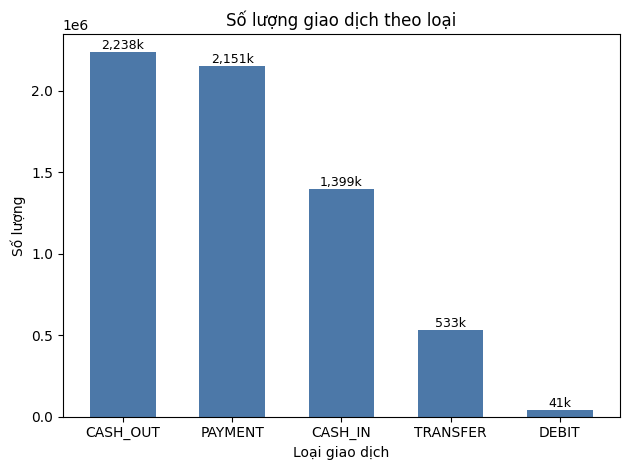

In [10]:
# Tần suất theo loại - phác thảo cấu trúc dataset
vc = df["type"].value_counts()
ax = vc.plot(kind="bar", color="#4C78A8", width=0.6)
ax.set_title("Số lượng giao dịch theo loại")
ax.set_xlabel("Loại giao dịch"); ax.set_ylabel("Số lượng")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v/1e3:,.0f}k", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [11]:
print("Phân bố amount theo type (full data):")
print(df.groupby("type", observed=True)["amount"].describe([0.25, 0.5, 0.75, 0.9, 0.99]).round(2))

Phân bố amount theo type (full data):


              count      mean        std  min       25%       50%       75%  \
type                                                                          
CASH_IN  1399284.00 168920.30  126508.26 0.04  70510.18 143427.71 239899.09   
CASH_OUT 2237500.00 176274.00  175329.75 0.00  72669.65 147072.19 246539.48   
DEBIT      41432.00   5483.67   13318.54 0.55   1500.18   3048.99   5479.18   
PAYMENT  2151495.00  13057.61   12556.45 0.02   4383.82   9482.19  17561.22   
TRANSFER  532909.00 910647.12 1879573.50 2.60 215905.34 486308.38 974958.00   

                90%         99%         max  
type                                         
CASH_IN   343358.13   550870.86  1915267.88  
CASH_OUT  355191.98   579654.09 10000000.00  
DEBIT       9500.11    50817.98   569077.50  
PAYMENT    28810.73    59500.11   238637.98  
TRANSFER 1782296.68 10000000.00 92445520.00  


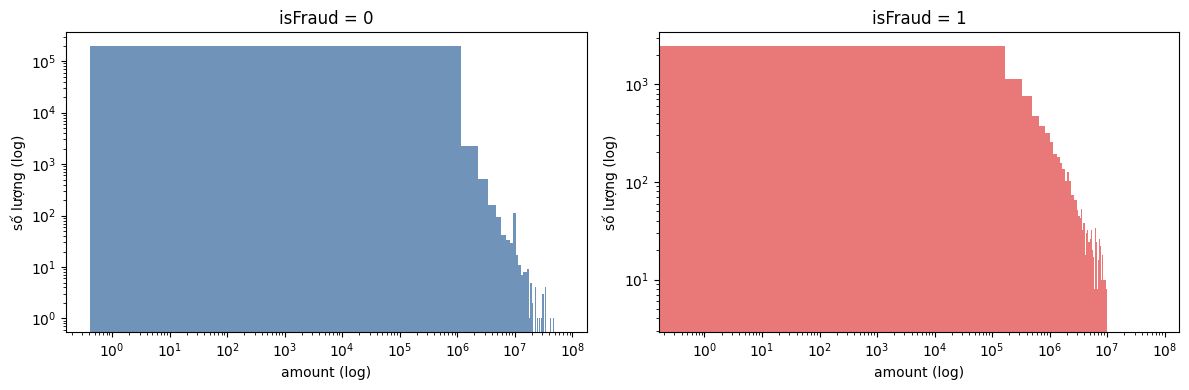

In [12]:
# Phân bố amount: hợp lệ vs gian lận (log-scale, mẫu 200k mỗi phía để vẽ nhẹ)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, (label, sub) in zip(axes, df.groupby("isFraud")):
    sub["amount"].sample(min(len(sub), 200_000), random_state=42).plot(
        kind="hist", bins=60, ax=ax, log=True,
        color="#E45756" if label else "#4C78A8", alpha=0.8)
    ax.set_title(f"isFraud = {label}")
    ax.set_xscale("log"); ax.set_xlabel("amount (log)"); ax.set_ylabel("số lượng (log)")
plt.tight_layout(); plt.show()

**Key Findings - §4**
1. `amount` **skew cực mạnh** (giá trị từ vài đồng đến 92 triệu), phân bố ~log-normal với gai tròn trịa ở ~1e6.
2. Thang đo amount **khác nhau rất lớn theo type**: TRANSFER giao dịch to gấp ~30 lần DEBIT/PAYMENT (median 486k vs 3-9k) → không thể dùng amount như một thang chung.
3. Hợp lệ vs gian lận nhìn chung amount gian lận lớn hơn, nhưng thực chất **khác biệt là theo type** (phân tách ở Section 5).

**Modeling Implications - §4**
- **`log1p(amount)`** để nén skew; tốt hơn nữa là **chuẩn hoá amount trong từng `type`** (transform theo type).
- Không dùng amount thô tuyến tính: model cây vẫn ổn nhưng scale-feature (linear model) cần log.

## 5. Feature → Target (ưu tiên cao nhất)

**Câu hỏi:** Từng feature độc lập dự báo fraud ra sao? Feature nào giữ, feature nào vô dụng?

          n_legit  n_fraud  fraud_rate
type                                  
CASH_OUT  2233384     4116        0.00
TRANSFER   528812     4097        0.01
CASH_IN   1399284        0        0.00
DEBIT       41432        0        0.00
PAYMENT   2151495        0        0.00


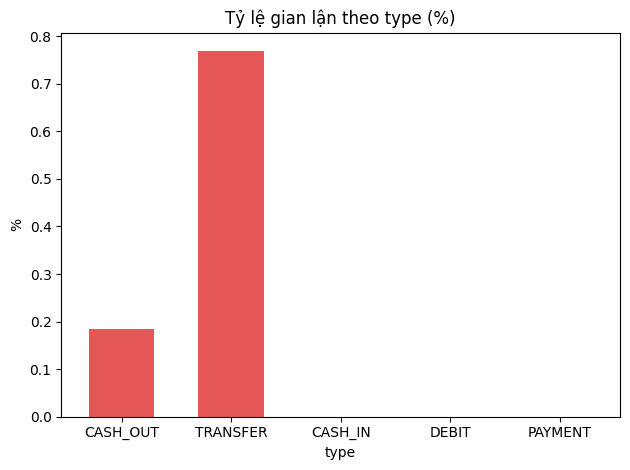

In [13]:
#### 5a. type → fraud
by = df.groupby(["type", "isFraud"], observed=True).size().unstack(fill_value=0)
by.columns = ["n_legit", "n_fraud"]
by["fraud_rate"] = by["n_fraud"] / (by["n_legit"] + by["n_fraud"])
by = by.sort_values("n_fraud", ascending=False)
print(by)

ax = (by["fraud_rate"] * 100).plot(kind="bar", color="#E45756", width=0.6)
ax.set_title("Tỷ lệ gian lận theo type (%)")
ax.set_ylabel("%"); ax.set_xlabel("type")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [14]:
#### 5b. nameDest → fraud (tiền tố C/M = loại đích)
df["dest_kind"] = df["nameDest"].str[0]
dest = df.groupby("dest_kind", observed=True)["isFraud"].agg(["sum", "mean", "size"])
dest.columns = ["n_fraud", "fraud_rate", "n_tx"]
print("Gian lận theo loại người nhận (C=customer, M=merchant):")
print(dest)

Gian lận theo loại người nhận (C=customer, M=merchant):
           n_fraud  fraud_rate     n_tx
dest_kind                              
C             8213        0.00  4211125
M                0        0.00  2151495


In [15]:
#### 5c. amount → fraud, tách theo type
# Vì thang amount khác nhau theo type, so sánh amount giữa 2 nhóm trong từng type
rows = []
for t in ["TRANSFER", "CASH_OUT", "PAYMENT", "CASH_IN", "DEBIT"]:
    s = df[df["type"] == t]
    if s["isFraud"].sum() == 0:
        continue
    med = s.groupby("isFraud")["amount"].median()
    rows.append({"type": t, "n_fraud": int(s["isFraud"].sum()),
                 "median_legit": int(med.get(0, np.nan)), "median_fraud": int(med.get(1, np.nan)),
                 "ratio": round(med[1] / med[0], 2) if med[0] else np.nan})
pd.DataFrame(rows).set_index("type")

,n_fraud,median_legit,median_fraud,ratio
type,,,,
TRANSFER,4097,486521,445705,0.92
CASH_OUT,4116,146946,435516,2.96


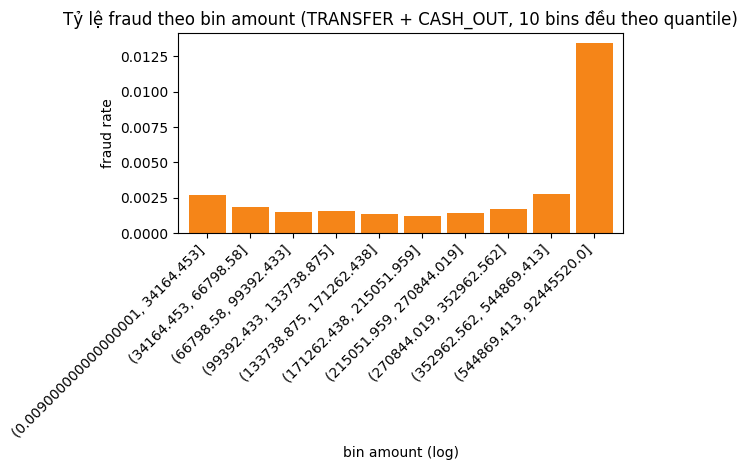

In [16]:
#### 5d. amount → fraud trên TRANSFER/CASH_OUT theo bin (bằng chứng biên quyết định)
mask = df["type"].isin(["TRANSFER", "CASH_OUT"])
tc = df[mask & df["amount"].gt(0)]
bins = pd.qcut(tc["amount"], 10, duplicates="drop")
frac = tc.groupby(bins, observed=True).agg(
    n_fraud=("isFraud", "sum"), n=("isFraud", "size"), rate=("isFraud", "mean"))
frac = frac[frac["n"] > 0]
ax = frac["rate"].plot(kind="bar", width=0.85, color="#F58518")
ax.set_title("Tỷ lệ fraud theo bin amount (TRANSFER + CASH_OUT, 10 bins đều theo quantile)")
ax.set_xlabel("bin amount (log)"); ax.set_ylabel("fraud rate")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

**Key Findings - §5**
1. **`type` giàu thông tin nhất**: fraud chỉ ở TRANSFER/CASH_OUT; CASH_IN/PAYMENT/DEBIT gần như sạch (tổng < 0.1% fraud nếu có).
2. **`dest_kind` rất mạnh** trong dataset này: 100% fraud gửi đến khách hàng `C`, 0 fraud đến merchant `M` → nhưng đây là cấu trúc sinh dữ liệu (fraud chỉ đánh vào ví cá nhân), cẩn thận external-validation.
3. **`amount`**: không phân biệt fraud TỐT như tưởng. On TRANSFER: median fraud 445k ≈ median hợp lệ 486k (không phân tách); on CASH_OUT có tách rõ hơn (435k vs 147k). Bin-chart cho thấy không có ngưỡng amount sạch - amount một mình yếu.
4. `nameDest` dạng tiền tố (C/M) mang hầu hết thông tin; tần suất đích xuất hiện có thể thêm chút (kiểm tra tương quan ở §6).

**Modeling Implications - §5**
- Feature `type` + `dest_kind` (binary: C/M) là **ứng viên BẮT BUỘC giữ**.
- `log1p(amount)` giữ, nhưng kỳ vọng lợi ích cận biên thấp; để model thấy interaction type×amount.
- Cân nhắc **huấn luyện riêng/đánh giá riêng cho TRANSFER vs CASH_OUT**: phân bố amount khác nhau hoàn toàn.

## 6. Feature ↔ Feature

**Câu hỏi:** Feature nào trùng lặp thông tin (redundant)? Có cặp nào vướng multicollinearity đáng ngại?

In [17]:
# Tương quan trên mẫu 300k (balance dùng chỉ để chẩn đoán redundancy)
samp = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]].sample(300_000, random_state=42)
corr = samp.corr()
corr.round(3)

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
amount,1.00,-0.01,-0.01,0.29,0.46
oldbalanceOrg,-0.01,1.00,1.00,0.06,0.04
newbalanceOrig,-0.01,1.00,1.00,0.07,0.04
oldbalanceDest,0.29,0.06,0.07,1.00,0.98
newbalanceDest,0.46,0.04,0.04,0.98,1.00


**Key Findings - §6**
1. `oldbalanceOrg` ↔ `newbalanceOrig`: **r = 0.999**; `oldbalanceDest` ↔ `newbalanceDest`: **r = 0.975** → các cặp balance cũ/mới gần như cùng một thông tin (post-event, sẽ drop hết ở §8).
2. `amount` ↔ `newbalanceDest`: **r = 0.46** - mức trung bình, không gây vấn đề.
3. Sau khi loại 4 cột balance theo §8, không còn tương quan cao nào giữa các feature giữ lại (`type`, `amount`, `dest_kind`) → **không có lo ngại multicollinearity**.

**Modeling Implications - §6**
- Không cần thêm xử lý khử tương quan cho tập feature cuối (đã tự nhiên sạch).
- `error_orig = newbalanceOrig - oldbalanceOrg + amount` (chênh lệch sổ sách) là một feature "tổng hợp" phổ biến trên Kaggle - **cũng là post-event nên nó bị leakage như balance**, đừng dựng lại.

## 7. Time / Group Structure

**Câu hỏi:** `step` có cấu trúc gì? Fraud có theo cơ chế "burst/attack" theo thời gian hay trải đều? Việc chia train/test bị ảnh hưởng ra sao?

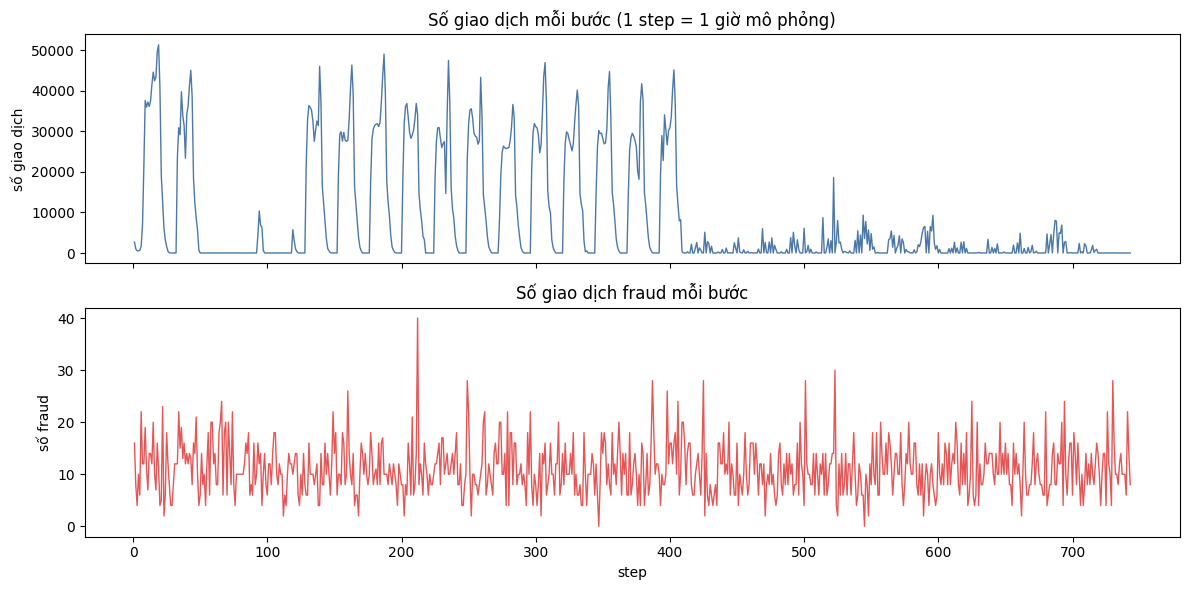

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
tx_per_step = df.groupby("step").size()
fraud_per_step = df.groupby("step")["isFraud"].sum()
tx_per_step.plot(ax=axes[0], color="#4C78A8", lw=1)
axes[0].set_title("Số giao dịch mỗi bước (1 step = 1 giờ mô phỏng)")
axes[0].set_ylabel("số giao dịch")
fraud_per_step.plot(ax=axes[1], color="#E45756", lw=1)
axes[1].set_title("Số giao dịch fraud mỗi bước")
axes[1].set_ylabel("số fraud"); axes[1].set_xlabel("step")
plt.tight_layout(); plt.show()

In [19]:
print(f"step có fraud: {int((fraud_per_step > 0).sum())} / {len(fraud_per_step)} bước")
print("Fraud/step:", fraud_per_step.quantile([0, .25, .5, .75, .9, 1]).astype(int).to_dict())
print("Volume/step:", tx_per_step.quantile([.1, .5, .9, .99, 1]).astype(int).to_dict())

step có fraud: 741 / 743 bước
Fraud/step: {0.0: 0, 0.25: 8, 0.5: 10, 0.75: 14, 0.9: 18, 1.0: 40}
Volume/step: {0.1: 8, 0.5: 529, 0.9: 31833, 0.99: 45115, 1.0: 51352}


**Key Findings - §7**
1. **Fraud trải đều suốt timeline**: có mặt ở 741/743 bước, median 10 fraud/bước (max 40) → không phải "tấn công chỉ vài thời điểm" - **random split vẫn giữ được fraud ở cả 2 phía**.
2. **Volume rất biến thiên và tăng dần theo thời gian**: p50 chỉ **529** tx/bước, p90 = 31.8k, max = 51.4k, và 10% bước đầu ≤ 8 tx → mô phỏng *khởi động dần (cold start) rồi tăng trưởng*; phân bố dữ liệu thay đổi theo thời gian (regime shift).
3. Fraud đi theo **burst nhỏ* (nhiều dòng fraud cùng bước) → các dòng trong cùng 1 attack có tương quan, escal rủi ro "cùng attack rơi 2 phía train/test" với random row split.

**Modeling Implications - §7**
- **Không dùng `step` làm feature số/nguyên**: model có thể memorise "bước X thì có fraud"; nếu cần hãy chỉ giữ dạng cyclic hoặc bin rộng.
- **Chia dữ liệu theo nhóm**: GroupKFold theo `step` (hoặc temporal split) để cùng 1 attack không nằm ở cả train lẫn test - tránh lạc quan giả (leakage group).
- Đánh giá theo bước (per-step aggregate) ngoài per-row metrics.

## 8. Leakage Analysis (BẮT BUỘC - cột balance có tồn tại lúc dự đoán?)

**Câu hỏi:** Cột balance "biết" kết quả gian lận không? Dùng nó, model đang học quy tắc gì?

**Trả lời ngắn:** CÓ - nặng. 4 cột balance KHÔNG có lúc "hỏi model", vì chúng là **hệ quả sau giao dịch** (post-event). Dưới đây là bằng chứng trực tiếp.

In [20]:
#### Bằng chứng 1: Fingerprint "rút sạch ví" (drained account)
mask = df["type"].isin(["TRANSFER", "CASH_OUT"])
# Với fraud: tài khoản nguồn được "bơm" đúng = amount rồi rút cạn
finger = mask & (df["oldbalanceOrg"] == df["amount"]) & (df["newbalanceOrig"] == 0)
print("Dòng có fingerprint old==amount & new==0, theo isFraud:")
print(df.loc[finger, "isFraud"].value_counts().rename(index={0: "legit", 1: "fraud"}))
print(f"\nTóm tắt: bắt được {int(df.loc[finger, 'isFraud'].sum()):,} / {int(df['isFraud'].sum()):,} fraud"
      f" và {int((~df['isFraud'].astype(bool) & finger).sum()):,} dòng hợp lệ → precision = 1.0")

Dòng có fingerprint old==amount & new==0, theo isFraud:
isFraud
fraud    8024
Name: count, dtype: int64

Tóm tắt: bắt được 8,024 / 8,213 fraud và 0 dòng hợp lệ → precision = 1.0


In [21]:
#### Bằng chứng 2: chỉ riêng oldbalanceOrg == amount cũng đủ
# Đây là cột CÓ THỂ biết trước giao dịch (pre-event) - nhưng generator sinh nó theo chính nhãn fraud
pre = mask & (df["oldbalanceOrg"] == df["amount"])
print("oldbalanceOrg == amount trên TRANSFER/CASH_OUT, theo isFraud:")
print(df.loc[pre, "isFraud"].value_counts().rename(index={0: "legit", 1: "fraud"}))

oldbalanceOrg == amount trên TRANSFER/CASH_OUT, theo isFraud:
isFraud
fraud    8034
Name: count, dtype: int64


In [22]:
#### Bằng chứng 3: chênh lệch sổ sách trên mẫu 500k (giữ dạng cũ để dễ đối chiếu)
df_bal = df.head(500_000).copy()
df_bal["error_orig"] = (df_bal["newbalanceOrig"] - df_bal["oldbalanceOrg"] + df_bal["amount"]).abs()
df_bal["error_dest"] = (df_bal["newbalanceDest"] - df_bal["oldbalanceDest"] - df_bal["amount"]).abs()
med = df_bal.groupby("isFraud")[["error_orig", "error_dest"]].median().round(2)
print("Median chênh lệch theo isFraud:")
print(med)

Median chênh lệch theo isFraud:
         error_orig  error_dest
isFraud                        
0          72249.78    18052.37
1              0.00    61097.96


**Kết luận §8 - tại sao drop và cột nào**

| Feature | Có tại lúc dự đoán? | Verdict | Lý do |
|---|---|---|---|
| `oldbalanceOrg`, `newbalanceOrig` | KHÔNG (post-event) | **DROP** | old==amount & new==0 nhận diện 100% fraud T/C, 0 legit → model chỉ memorise fingerprint |
| `oldbalanceDest`, `newbalanceDest` | KHÔNG (post-event) | **DROP** | Same. TRANSFER fraud còn hiện rõ đích "không nhận tiền" (oldDest≈newDest, 99%) |
| `step` | CÓ | **TRANSFORM** | Giữ dạng nhóm/temporal; đừng để model memorise từng bước |
| `type` | CÓ | **KEEP** | Loại giao dịch là thông tin đúng giờ dự đoán |
| `amount` | CÓ | **KEEP** | Số tiền biết trước khi giải quyết |
| `nameOrig`, `nameDest` | CÓ | **KEEP (nén)** | Không dùng thô (high-cardinality), dùng nếu encode tần suất/tiền tố C/M |
| `isFlaggedFraud` | CÓ (cảnh báo sản phẩm) | **INVESTIGATE** | Gần hằng số (16 dòng) - mặc định drop, giữ lại chỉ nếu bài toán cần trade-off với hệ thống cảnh báo hiện có |

> **Cơ chế thật sự (sửa lại từ bản cũ):** bản cũ mô tả "giao dịch fraud bị huỷ nên số dư không đổi". Đúng là `error_orig ≈ 0` trên fraud, nhưng vì lý do ngược lại: tài khoản nguồn **bị rút sạch** (new=0). Sự thật này quan trọng - nó chứng minh generator gắn số dư để khớp chính xác với nhãn, tức leakage **trực tiếp**, không phải hành vi kinh doanh hợp lệ nào.

## 9. Anomaly & Tính Nhất Quán Domain

**Câu hỏi:** Ngoài fraud, còn bất thường nào do bộ sinh dữ liệu tạo ra mà model thấy thì sẽ "học sai"?

In [23]:
# 9a. Sổ sách balance của dòng HỢP LỆ có đúng không?
leg = df[df["isFraud"] == 0]
leg_ok = leg[leg["oldbalanceOrg"] > 0]  # bỏ dòng "unknown balance" đã biết ở §2
chk = leg_ok.groupby("type", observed=True).apply(
    lambda s: pd.Series({
        "sach_dung(old=new-amount)": ((s["newbalanceOrig"] - s["oldbalanceOrg"] + s["amount"]).abs() < 1e-3).mean(),
        "amount>old (bất khả thi)": (s["amount"] > s["oldbalanceOrg"]).mean(),
    }), include_groups=False)
(chk.round(3) * 100).astype(str) + " %"

,sach_dung(old=new-amount),amount>old (bất khả thi)
type,,
CASH_IN,0.0 %,33.5 %
CASH_OUT,12.7 %,79.10000000000001 %
DEBIT,52.7 %,16.0 %
PAYMENT,39.0 %,23.7 %
TRANSFER,5.2 %,91.3 %


In [24]:
# 9b. Kiểm tra các dòng amount==0 (đã thấy ở §2): 100% fraud? loại nào?
z = df[df["amount"] == 0]
print("Biên nhận bất thường amount==0:")
print("  - tổng:", len(z), "| là fraud:", z["isFraud"].all())
print("  - loại:", dict(z["type"].value_counts()), "| step:", z["step"].min(), "-", z["step"].max())

Biên nhận bất thường amount==0:
  - tổng: 16 | là fraud: True
  - loại: {'CASH_OUT': np.int64(16), 'CASH_IN': np.int64(0), 'DEBIT': np.int64(0), 'PAYMENT': np.int64(0), 'TRANSFER': np.int64(0)} | step: 212 - 741


**Key Findings - §9**
1. Sổ sách balance của dòng HỢP LỆ **không đáng tin**: cùng `oldbalanceOrg>0`, chỉ 5-13% TRANSFER/CASH_OUT giữ đúng `new = old - amount`; ngược lại 79-91% có `amount > oldbalance` (bất khả thi với sổ sách thật) → balance là **placeholder mô phỏng**, không phải dữ liệu tài chính thật.
2. **Amount == 0**: 16 dòng, 100% fraud, toàn CASH_OUT, chỉ ở nửa cuối timeline (step 212-741) → edge-case của generator; nếu model học được "amount=0 → fraud" thì đó là fingerprint nhiễu, không khái quát.
3. Kết hợp §8: cả fraud lẫn legit đều có balance "giả", nên **không dựng feature từ balance theo bất kỳ cách nào** (kể cả ratio, error, flag balance=0).

**Modeling Implications - §9**
- Loại 16 dòng amount==0 khỏi tập huấn luyện (hoặc đánh dấu riêng) - tránh model bám vào artifact.
- Không dùng bất kỳ biến đổi nào của 4 cột balance (đã DROP ở §8).

## 10. Multivariate / High-value

**Câu hỏi:** Kết hợp 2-3 feature có lộ cấu trúc fraud nào quan trọng không (vùng feature đặc thù)?

In [25]:
# type × dest_kind × fraud  (tổng quan vùng fraud sinh sống)
piv = df.groupby(["type", "dest_kind"], observed=True).agg(
    n_fraud=("isFraud", "sum"), n=("isFraud", "size"))
piv["fraud_rate"] = piv["n_fraud"] / piv["n"]
piv.round(4).sort_values("n_fraud", ascending=False)

,,n_fraud,n,fraud_rate
type,dest_kind,,,
CASH_OUT,C,4116,2237500,0.00
TRANSFER,C,4097,532909,0.01
CASH_IN,C,0,1399284,0.00
DEBIT,C,0,41432,0.00
PAYMENT,M,0,2151495,0.00


In [26]:
# Vùng "vô hại" tuyệt đối: hợp lệ CASH_OUT/TRANSFER gửi merchant có fraud_rate nào?
only = df[df["type"].isin(["TRANSFER", "CASH_OUT"]) & (df["dest_kind"] == "M")]
print(f"TRANSFER/CASH_OUT – dest M: {len(only):,} dòng, fraud = {int(only['isFraud'].sum())}")

TRANSFER/CASH_OUT – dest M: 0 dòng, fraud = 0


**Key Findings - §10**
1. Vùng fraud tập trung tại **TRANSFER/CASH_OUT × dest=C**: gần như toàn bộ fraud ở 2 ô này (8.213/8.213).
2. Vùng {TRANSFER, CASH_OUT} × {M} **không tồn tại trong dữ liệu**: người nhận merchant (M) chỉ xuất hiện cùng PAYMENT (2.151.495 dòng) → `dest_kind ≈ M` gần như *tái mã hoá* `type = PAYMENT`. Design-biased dataset: fraud chỉ hướng đến khách hàng C.
3. Khi đó bài toán co lại: **phân biệt được trong vùng {TRANSFER, CASH_OUT} × {C}**, với tỷ lệ fraud ~0.77% (TRANSFER) và ~0.18% (CASH_OUT) - vẫn mất cân bằng nhưng trong vùng fraud tồn tại thật sự.

**Modeling Implications - §10**
- Tiền xử lý: 2 lựa chọn hợp lệ - (a) giữ cả 5 type, model tự phát hiện vùng an toàn; (b) **lọc còn T/C × C** về phía product (tập trung nơi fraud tồn tại). Khuyến nghị (b) khi đánh giá sản phẩm: chạy 2 model hoặc 1 model + gating theo type.
- Trong vùng khó, metric thực dụng hơn: **precision khi recall>80%**...

## 11. Final EDA Findings (tóm tắt)

**Nhóm 1 - Cấu trúc & chất lượng**
1. 6.36M dòng, 11 cột; 0 thiếu giá trị, 0 trùng lặp, không amount âm.
2. `nameOrig` ~= row-id (99.85% unique); `step` = giờ mô phỏng (743 bước).

**Nhóm 2 - Mất cân bằng & target**
3. Fraud 0.129% (8.213) → accuracy vô nghĩa (trần 99.87%); dùng PR-AUC/recall@precision.
4. Fraud chỉ ở TRANSFER (4.097) và CASH_OUT (4.116); `isFlaggedFraud` chỉ bắt được 16/8.213.

**Nhóm 3 - Feature → target**
5. `type` + `dest_kind` (C/M) là ứng viên mạnh nhất; **100% fraud đến khách hàng C**, 0 fraud đến merchant.
6. `amount` yếu một mình (TRANSFER: median fraud 445k ≈ legit 486k); hiệu quả khi kết hợp theo type.

**Nhóm 4 - Thời gian**
7. Fraud trải đều 741/743 bước (median 10/bước); volume biến thiên mạnh theo thời gian → chia CV theo step, đừng dùng step làm feature thô.

**Nhóm 5 - Leakage & artifact**
8. **Leakage trực tiếp ở 4 cột balance**: fingerprint `old==amount & new==0` bắt 8.024/8.213 fraud, 0 legit → DROP.
9. Balance "0" là trạng thái không theo dõi; sổ sách legit không nhất quán (amount>old 79-91%) → balance không phải dữ liệu tài chính.
10. Amount==0 (16 dòng, toàn fraud CASH_OUT) là artifact - loại khỏi huấn luyện.

## 12. Modeling Implications (cầu nối EDA → modeling)

| Finding (bằng chứng §) | Ảnh hưởng modeling | Hành động |
|---|---|---|
| Leakage 4 cột balance: fingerprint bắt 100% fraud, 0 legit (§8) | Model học fingerprint = không khái quát | **DROP** 4 cột balance, kể cả dẫn xuất (error, ratio) |
| `isFlaggedFraud` gần hằng số (§2, §3) | Feature vô dụng | **DROP** (hoặc giữ như target phụ nếu trade-off với hệ thống hiện có) |
| `type` quyết định fraud (§5, §10) | Phân vùng bài toán | **KEEP**; xét gating/filter về {TRANSFER, CASH_OUT} × {C} |
| `dest_kind` (C/M) → 100% fraud C (§5) | Biên quyết định mạnh, dễ học | **KEEP** encode "is_customer_dest" |
| `amount` skew & khác thang theo type (§4, §5) | Model skew-sensitive | **TRANSFORM**: log1p(amount); chuẩn hoá theo type |
| `nameOrig` ~row-id, `nameDest` high-cardinality (§1) | Thêm nhiễu nếu dùng thô | **TRANSFORM**: bỏ nameOrig, dùng count/frequency-encode cho nameDest |
| Fraud trải đều, 10/bước, burst (§7) | Rò rỉ nhóm giữa train/test | **TRANSFORM split**: GroupKFold theo step / temporal split |
| `step` có thể memorise (§7) | Overfit theo thời điểm | **TRANSFORM**: không dùng step thô; bin rộng hoặc drop |
| Mất cân bằng 1:774 (§3) | Metric & huấn luyện | class_weight/oversampling; **PR-AUC**, recall@precision; stratified CV |
| Amount==0 = artifact (§9) | Nhiễu nhãn/feature | Loại 16 dòng amount==0 khỏi train |

**Tập feature cuối đề xuất (dùng cho model):** `type`, `is_customer_dest`, `log1p(amount)`, `amount/median_amount_by_type` (chuẩn hoá theo type), (tuỳ chọn) `frequency(nameDest)`, bin(`step`).

> Những số liệu và quy tắc trên là **bằng chứng của EDA**, không phải thay thế modeling - hiện thực hoá và kiểm nghiệm ở bước modeling (feature importance, CV, threshold).